# ML Foundations – Assignment 1: Data Preparation

**Author:** Nikoloz Chachia  
**GitHub Repository:** https://github.com/nika140906/ML-fundamentals-2026

## Step 1 — Task Ordering

The tasks are listed alphabetically in the assignment, but that is obviously not the order you would 
actually do them. Below is the order I chose and my reasoning for each step.

| Step | Task | Why this position | What I can use here | What I must not use | What goes wrong if order changes |
|------|------|-------------------|--------------------|--------------------|----------------------------------|
| 1 | Identifying the Prediction Target | You need to know what you are predicting before anything else makes sense | Problem description and column names | Any data values | You might engineer features or drop columns based on the wrong objective |
| 2 | Data Loading and Exploration | You need to see the raw data before touching it | Full raw dataset, for observation only | No fitting of any kind | You would be making preprocessing decisions blind |
| 3 | Data Splitting | Has to happen before any preprocessing, otherwise the test set gets contaminated | Raw features and target variable | Any computed statistics from the data | If you scale or impute first, the scaler has already seen the test data — evaluation becomes meaningless |
| 4 | Managing Missing Values | Now that we have splits, we can fit the imputer on training data only | Training set mode/statistics | Anything from validation or test sets | Imputer learns from test data and carries that information into the model |
| 5 | Encoding Categorical Variables | Encoders need to be fit on training data only, same logic as imputation | Training set category levels | Category levels from val/test | Encoder might learn categories that only exist in the test set |
| 6 | Feature Scaling | Scaler must be fit on training data only | Training set mean and std | Val/test statistics | Test set distribution leaks into the scaler, evaluation is too optimistic |
| 7 | Feature Selection | Selection must be based on training data only, after scaling | Training set variance, correlations, F-scores | Any val/test information | Features get selected based on patterns in the test set, not just training |
| 8 | Addressing Class Imbalance | SMOTE goes last in preprocessing — only on training data | Resampled training set | Val/test sets must stay untouched | Synthetic samples leak into val/test, making results look better than they are |
| 9 | Training Logistic Regression | Everything is ready now | Preprocessed and resampled training set | Test set — only val set used here | Peeking at test set performance leads to decisions that overfit to it |

### Example of Incorrect Ordering

A classic mistake is applying SMOTE before splitting the data. SMOTE generates synthetic minority 
samples by interpolating between existing ones — but if you do this on the full dataset first, some 
of those synthetic samples will end up in your validation and test sets. Those sets are supposed to 
represent real unseen clients, but now they contain made-up examples that are essentially copies of 
training data. Your accuracy and recall will look better than they really are, and you have no way 
of knowing how the model would actually perform in production.

#### Example of Incorrect Ordering

If you apply SMOTE before splitting, the synthetic samples it generates 
could end up in both the training and test sets. That means the test set 
is no longer independent, and your evaluation results will look better 
than they actually are.


## Step 2 — Identifying the Prediction Target

The target variable is **`y`** — a binary column that tells us whether 
a client subscribed to a term deposit after being contacted ('yes' or 'no').

This is the right target because the whole point of the campaign was to 
get clients to subscribe. The variable is only known after the call, 
which means it is what we are trying to predict — not something we 
already know at contact time.

### Variables that should NOT be treated as the target:

1. **`duration`** — This is how long the phone call lasted. It sounds 
useful but the problem is we only know it after the call is over. 
If we used it as a feature it would leak information about the outcome, 
and it makes no sense as a target variable either.

2. **`campaign`** — This counts how many times the client was contacted 
during the campaign. It describes what we did, not what happened as a 
result, so it is not a meaningful prediction objective.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading the dataset
df = pd.read_csv('bank-additional.csv', sep=';')

# quick look at the first few rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [2]:
# Dataset structure
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:")
df.describe()

Shape: (4119, 21)

Data types:
 age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Basic statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Step 3 — Data Loading and Exploration

The dataset contains 4119 rows and 21 columns. The variables are a mix 
of numerical (int64, float64) and categorical (object) types.

Numerical variables: age, duration, campaign, pdays, previous, 
emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

Categorical variables: job, marital, education, default, housing, 
loan, contact, month, day_of_week, poutcome, y

In [3]:
# Target variable distribution
print("Target variable distribution:")
print(df['y'].value_counts())
print("\nPercentage:")
print(df['y'].value_counts(normalize=True).round(3) * 100)

Target variable distribution:
y
no     3668
yes     451
Name: count, dtype: int64

Percentage:
y
no     89.1
yes    10.9
Name: proportion, dtype: float64


The target variable is heavily imbalanced — 89.1% of clients did not 
subscribe and only 10.9% did. This means a model that always predicts 
"no" would be 89% accurate, which is misleading. We will need to address 
this imbalance later using resampling on the training set only.

In [4]:
# check for explicit missing values (NaN)
print("Explicit missing values (NaN):")
print(df.isnull().sum())

# check for implicit missing values ('unknown' string)
print("\nImplicit missing values ('unknown'):")
for col in df.select_dtypes(include='str').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"  {col}: {count} ({round(count/len(df)*100, 1)}%)")

Explicit missing values (NaN):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Implicit missing values ('unknown'):
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)


In [5]:
# pdays = 999 means the client was never previously contacted
# this is a sentinel value, not a real number of days
print("pdays value of 999 (never contacted):", (df['pdays'] == 999).sum())
print("pdays other values:", (df['pdays'] != 999).sum())

pdays value of 999 (never contacted): 3959
pdays other values: 160


The pdays column uses 999 as a sentinel value meaning the client was 
never previously contacted — not that they were contacted 999 days ago. 
We will create a binary flag for this in feature engineering.

There are no explicit missing values (NaN) in the dataset. However, 
several categorical columns contain the value 'unknown' which represents 
implicit missing values — data that was not collected or not available.

The most affected columns are:
- default: 803 unknown values (19.5% of rows)
- education: 167 unknown values
- housing and loan: 105 each
- job: 39 unknown values
- marital: 11 unknown values

We will handle these in Step 5 (Managing Missing Values) after splitting 
the data, to avoid any leakage into the validation and test sets.

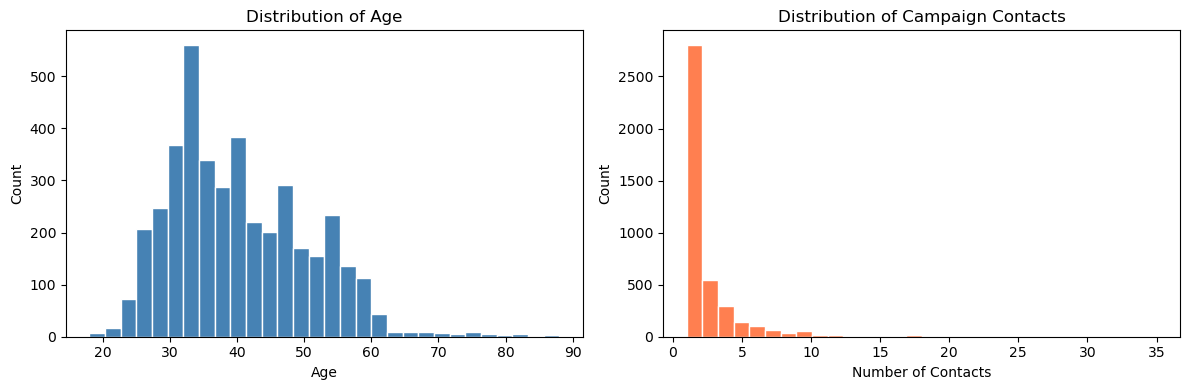

In [6]:
# Visualize two numerical variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Campaign distribution
axes[1].hist(df['campaign'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Campaign Contacts')
axes[1].set_xlabel('Number of Contacts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

The age distribution is roughly bell-shaped, with most clients between 
25 and 50 years old. The campaign variable is heavily right-skewed — 
most clients were contacted only once or twice, but a small number were 
contacted up to 35 times. This extreme skewness in campaign will need 
to be considered during feature scaling.

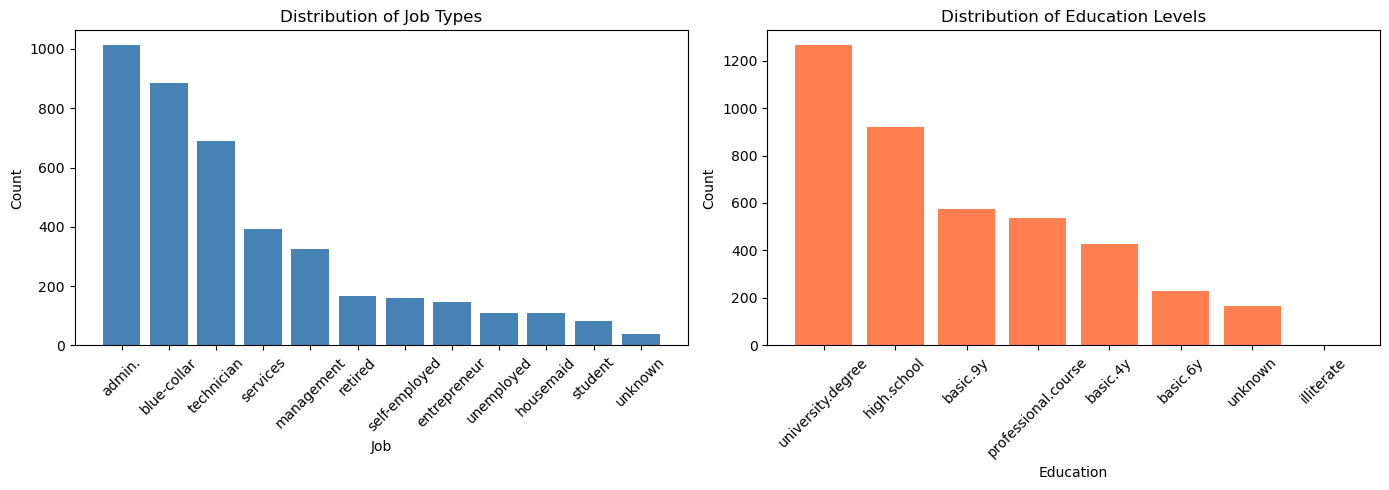

In [7]:
# Visualize two categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Job distribution
job_counts = df['job'].value_counts()
axes[0].bar(job_counts.index, job_counts.values, color='steelblue')
axes[0].set_title('Distribution of Job Types')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Education distribution
edu_counts = df['education'].value_counts()
axes[1].bar(edu_counts.index, edu_counts.values, color='coral')
axes[1].set_title('Distribution of Education Levels')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The most common job types are admin, blue-collar and technician. 
The education plot shows that most clients have a university degree 
or high school education. We can also clearly see the 'unknown' 
category in both plots, confirming the implicit missing values 
we identified earlier.

### Variable Requiring Special Consideration

**`duration`** — This variable records how long the phone call lasted. 
It is strongly correlated with the outcome (longer calls tend to result 
in subscriptions) but it is only known after the call ends. This means 
it cannot be used as a feature at prediction time — using it would 
cause data leakage. We will remove it from the feature set before 
training the model.

## Step 4 — Data Splitting

The first thing we need to do before any preprocessing is split the data into three sets:

- Training set (70%) — this is what we use to fit everything
- Validation set (15%) — used to check how things are going during development
- Test set (15%) — only touched at the very end

The split has to happen before any preprocessing. If we scaled or imputed first, the scaler or 
imputer would have already seen the test data when computing its parameters. This is called 
preprocessing leakage, the test set influences how the training data gets transformed, so the 
final evaluation no longer reflects how the model would perform on genuinely new data. Similarly, 
if feature selection were done before splitting, the selector would pick features based on patterns 
in the test set too, not just the training data. Both types of leakage make results look better 
than they actually are.

We use stratified splitting because the classes are imbalanced (89% no, 11% yes). Without 
stratification we might end up with a split where one set has very few "yes" examples, which would 
make training and evaluation unreliable.

duration is dropped here before splitting. It records how long the call lasted, which is only 
known after the call ends, so it cannot be used as a feature at prediction time.


In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['y', 'duration'])
y = df['y']

# First split: training (70%) and temporary (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (2883, 19)
Validation set: (618, 19)
Test set: (618, 19)


Split looks good — 2883 for training, 618 each for validation and test. 
I dropped duration here since we established earlier that it leaks 
information about the outcome. Used stratify to make sure the class 
imbalance (89/11 split) carries over into all three sets, otherwise 
we might get unlucky and have barely any "yes" cases in one of them.


## Step 5 — Managing Missing Values

There are no NaN values in this dataset, so there are no explicit missing values to deal with. 
However, several columns contain 'unknown' as a string, which are implicit missing values — 
data that was never collected or recorded properly.

For job, marital, education, housing and loan the number of unknowns is small, so I replaced 
them with the most frequent value (mode imputation). This is a data cleaning decision — the 
unknowns are likely just gaps in data collection, not meaningful on their own.

For default I kept 'unknown' as its own category. With 803 unknowns (19% of rows), imputing 
would mean inventing values for a large chunk of the data. More importantly, whether someone's 
credit default status is unknown might actually carry predictive signal — it could mean the bank 
simply does not have that information for certain clients. That makes it a modeling decision, not 
just a cleaning one.

The mode is fitted on the training set only and then applied to validation and test. If we 
computed the mode on the full dataset first, we would be letting test set values influence how 
we fill in training data.

In [9]:
# Columns with 'unknown' to impute with mode (low count)
cols_to_impute = ['job', 'marital', 'education', 'housing', 'loan']

# Fit mode on training set only
modes = X_train[cols_to_impute].mode().iloc[0]

# Apply to all three sets
X_train[cols_to_impute] = X_train[cols_to_impute].replace('unknown', modes)
X_val[cols_to_impute] = X_val[cols_to_impute].replace('unknown', modes)
X_test[cols_to_impute] = X_test[cols_to_impute].replace('unknown', modes)

# Keep 'unknown' as a category for default (too many to impute)
# Verify unknowns remaining
print("Remaining unknowns after imputation:")
for col in X_train.select_dtypes(include='str').columns:
    count = (X_train[col] == 'unknown').sum()
    if count > 0:
        print(f"{col}: {count}")
print("Done!")

Remaining unknowns after imputation:
default: 577
Done!


## Step 6 — Encoding Categorical Variables

Logistic regression can't work with text categories directly, so we need to convert them to 
numbers.

The first thing I had to figure out was which columns are nominal and which are ordinal, because 
that changes how we encode them.

Education is ordinal. There is a clear progression from illiterate up to university degree, so it 
makes sense to encode this as integers 0 to 6 so the model understands that university degree is 
higher than high school. I used OrdinalEncoder for this.

Everything else (job, marital, default, housing, loan, contact, month, day_of_week, poutcome) is 
nominal. There is no meaningful order between categories like admin and technician, so I used 
OneHotEncoder with drop='first' to turn each category into a binary column.

The drop='first' part matters for logistic regression specifically. If you keep all dummy columns, 
one is always perfectly predictable from the others, which causes multicollinearity and makes the 
coefficients unreliable. Dropping one column per variable also keeps the decision boundary cleaner 
since logistic regression draws a linear boundary in feature space, and redundant binary columns 
just add dimensions that carry no new information.

After encoding the dataset went from 19 to 42 columns. Encoders are fitted on training data only 
and then applied to validation and test.

In [10]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import numpy as np

# education has a clear order so we encode it as integers 0-6
education_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree', 'unknown'
]

# everything else has no meaningful order so one-hot encoding makes more sense
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']

# fit ordinal encoder on training set only
ord_encoder = OrdinalEncoder(categories=[education_order])
X_train['education'] = ord_encoder.fit_transform(X_train[['education']])
X_val['education'] = ord_encoder.transform(X_val[['education']])
X_test['education'] = ord_encoder.transform(X_test[['education']])

# fit one-hot encoder on training set only, drop='first' to avoid multicollinearity
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[nominal_cols])
X_train_enc = encoder.transform(X_train[nominal_cols])
X_val_enc = encoder.transform(X_val[nominal_cols])
X_test_enc = encoder.transform(X_test[nominal_cols])

# replace original categorical columns with the encoded ones
enc_cols = encoder.get_feature_names_out(nominal_cols)
X_train = pd.concat([X_train.drop(columns=nominal_cols).reset_index(drop=True),
                     pd.DataFrame(X_train_enc, columns=enc_cols)], axis=1)
X_val = pd.concat([X_val.drop(columns=nominal_cols).reset_index(drop=True),
                   pd.DataFrame(X_val_enc, columns=enc_cols)], axis=1)
X_test = pd.concat([X_test.drop(columns=nominal_cols).reset_index(drop=True),
                    pd.DataFrame(X_test_enc, columns=enc_cols)], axis=1)

print("Shape after encoding:", X_train.shape)
print("\nEducation encoded values (sample):")
print(X_train['education'].value_counts().sort_index())

Shape after encoding: (2883, 42)

Education encoded values (sample):
education
0.0       1
1.0     292
2.0     155
3.0     396
4.0     661
5.0     376
6.0    1002
Name: count, dtype: int64



First thing I needed to figure out was which columns are nominal and 
which are ordinal, because that changes how we encode them.

**Ordinal** (there's a clear order):
- `education` goes from illiterate all the way up to university degree. 
It makes sense to encode this as numbers 0-6 so the model knows that 
university degree > high school > basic. Used OrdinalEncoder for this.

**Nominal** (no meaningful order):
- everything else: job, marital, default, housing, loan, contact, month, 
day_of_week, poutcome. There's no reason to say admin > technician for 
example, so I used OneHotEncoder with drop='first' to turn each category 
into a binary column.

The drop='first' part is important for logistic regression. If you keep 
all dummy columns, one is always predictable from the others which causes 
multicollinearity. After encoding the dataset went from 19 to 42 columns. 
As always, encoders are fitted on training data only.

## Step 7 — Feature Scaling

I used StandardScaler which transforms each feature to mean=0 and std=1. 
Here is why this matters for logistic regression:

**Gradient descent** works much faster when features are on the same scale. 
If one feature ranges from 0 to 100000 and another from 0 to 1, the 
loss surface becomes elongated and gradient descent takes much longer 
to converge.

**Regularization** also becomes unfair without scaling. The penalty term 
treats all coefficients equally, so a feature with large raw values gets 
penalised more heavily just because of its scale, not because it is less 
important.

**Coefficient comparability** -- after scaling we can actually compare 
coefficients and say which features have more influence on the prediction. 
Without scaling this comparison is meaningless.

Only numerical columns are scaled. Scaler is fitted on training data only.

In [11]:
from sklearn.preprocessing import StandardScaler

# figure out which columns actually need scaling
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print("Numerical columns to scale:", num_cols)

# fit on training data only, never let the scaler see val or test
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

# apply the same transformation to all three sets
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# check that mean is ~0 and std is ~1 across the board
print("\nAfter scaling - training set stats:")
print(X_train[num_cols].describe().round(2))

Numerical columns to scale: ['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'default_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']

After scaling - training set stats:
           age  education  campaign    pdays  previous  emp.var.rate  \
count  2883.00    2883.00   2883.00  2883.00   2883.00       2883.00   
mean     -0.00       0.00     -0.00    -0.00      0.00         -0.00   
std       1.00       1.00      1.00     1.00      1.0

Scaling worked correctly — all features now have mean of 0 and 
standard deviation of 1. Notice that the binary encoded columns 
also got scaled, which is fine for logistic regression.


## Step 8 — Feature Selection

I did feature selection in three steps.

First I checked for low variance features using a threshold of 0.01 — if a feature barely changes 
across samples it is unlikely to help the model. Nothing was removed here.

Then I checked for highly correlated features using a threshold of 0.85. Keeping two features that 
say essentially the same thing causes multicollinearity, which makes logistic regression 
coefficients unstable. This removed euribor3m, nr.employed and poutcome_success.

Finally I used SelectKBest with the ANOVA F-test to keep the top 20 features most related to the 
target.

There is also a conceptual reason to remove features beyond statistics. duration was dropped in 
Step 4 because it is only known after the call ends — using it would mean training on information 
that does not exist at prediction time. Every feature in the final model needs to be something you 
would actually have when making a real prediction.

All selection steps are fitted on training data only. If feature selection were done on the full 
dataset before splitting, the selector would have seen test data when computing its scores. It 
would pick features that look predictive on the test set specifically, not just the training data, 
and the final evaluation results would be misleadingly optimistic.

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

# drop anything that barely changes across samples, unlikely to help the model
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train)
X_train = pd.DataFrame(var_selector.transform(X_train), 
                       columns=X_train.columns[var_selector.get_support()])
X_val = pd.DataFrame(var_selector.transform(X_val),
                     columns=X_train.columns)
X_test = pd.DataFrame(var_selector.transform(X_test),
                      columns=X_train.columns)
print("After variance threshold:", X_train.shape)

# find features that are telling the same story and keep only one of them
num_cols = X_train.select_dtypes(include='number').columns
corr_matrix = X_train[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Highly correlated features removed:", high_corr)
X_train = X_train.drop(columns=high_corr)
X_val = X_val.drop(columns=high_corr)
X_test = X_test.drop(columns=high_corr)
print("After correlation filter:", X_train.shape)

# keep the top 20 features most related to the target
selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_train, y_train)
X_train_sel = selector.transform(X_train)
X_val_sel = selector.transform(X_val)
X_test_sel = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
scores = selector.scores_[selector.get_support()]
feature_scores = pd.DataFrame({
    'Feature': selected_features,
    'Score': scores
}).sort_values('Score', ascending=False)

print("\nTop 20 selected features:")
print(feature_scores.to_string(index=False))
print("\nFinal shape:", X_train_sel.shape)

After variance threshold: (2883, 42)
Highly correlated features removed: ['euribor3m', 'nr.employed', 'poutcome_success']
After correlation filter: (2883, 39)

Top 20 selected features:
             Feature      Score
               pdays 377.453539
        emp.var.rate 254.282040
            previous 242.923095
poutcome_nonexistent 140.411735
           month_mar  72.997655
           month_sep  66.553618
   contact_telephone  49.775383
           month_dec  31.193337
           month_may  25.188966
      cons.price.idx  24.872951
         job_student  20.585609
           month_oct  20.585609
            campaign  19.054179
     default_unknown  16.561920
      marital_single  14.468567
       cons.conf.idx  14.439957
           education  10.162085
         job_retired  10.055974
     job_blue-collar   9.705286
     marital_married   6.738603

Final shape: (2883, 20)


3 features were removed due to high correlation (euribor3m, nr.employed 
and poutcome_success are all strongly correlated with other features). 
After that SelectKBest picked the top 20. Interestingly education made 
it into the top 20 which suggests the ordinal encoding was a good call. 
The dataset went from 47 features all the way down to 20.

## Step 9 — Addressing Class Imbalance

The training set is still 89/11 which is a real problem. A model that 
just always guesses "no" would get 89% accuracy, which looks good on 
paper but would never actually find any subscribers.

I went with SMOTE over simple oversampling because it generates new 
synthetic minority examples by interpolating between existing ones, 
rather than just copying them. This means the model sees more variety 
in the minority class which should help it learn a better decision 
boundary. The assumption is that the area between minority samples is 
valid space for new examples, which seems reasonable here.

SMOTE only touches the training set. If I had applied it before 
splitting, synthetic samples could have ended up in the validation and 
test sets. Those sets would no longer represent real unseen data and 
any evaluation results would be meaningless.

Accuracy is a bad metric here because of the imbalance. Precision and 
recall are what actually matter -- precision tells us how many of our 
"yes" predictions were right, recall tells us how many real subscribers 
we actually caught.

In [13]:
from imblearn.over_sampling import SMOTE

# how bad is the imbalance before we do anything?
print("Before SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3) * 100)

# apply SMOTE to training set only, val and test stay untouched
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)

# confirm it worked
print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())
print(pd.Series(y_train_res).value_counts(normalize=True).round(3) * 100)

Before SMOTE:
y
no     2567
yes     316
Name: count, dtype: int64
y
no     89.0
yes    11.0
Name: proportion, dtype: float64

After SMOTE:
y
no     2567
yes    2567
Name: count, dtype: int64
y
no     50.0
yes    50.0
Name: proportion, dtype: float64


After SMOTE the training set went from 2883 to 5134 samples with a 
perfect 50/50 split. The validation and test sets are untouched and 
still have the original 89/11 distribution, which is what we want 
since they represent real unseen data.

## Step 10 — Training a Logistic Regression Model

This is a sanity check to verify the pipeline is working correctly. 
The goal is not to get the best possible accuracy but to check that 
the data preparation steps produce sensible results.

I train on the SMOTE-balanced training set and evaluate on the 
validation set which still has the original class distribution. 
I report accuracy, precision and recall, and compare accuracy against 
the zero rule baseline (always predicting the majority class).

Accuracy:           0.840
Zero Rule Baseline: 0.890
Precision:          0.374
Recall:             0.676


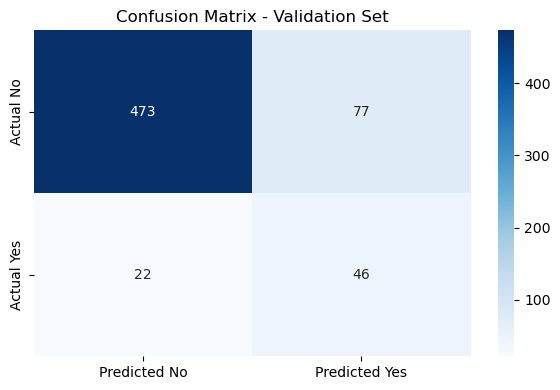

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# train on the SMOTE balanced set
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_res, y_train_res)

# run predictions on the validation set (original distribution, untouched)
y_pred = lr.predict(X_val_sel)

# how does the model do vs just always guessing "no"?
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, pos_label='yes')
recall = recall_score(y_val, y_pred, pos_label='yes')
zero_rule = y_val.value_counts(normalize=True).max()

print(f"Accuracy:           {accuracy:.3f}")
print(f"Zero Rule Baseline: {zero_rule:.3f}")
print(f"Precision:          {precision:.3f}")
print(f"Recall:             {recall:.3f}")

# visualise where the model gets it right and wrong
cm = confusion_matrix(y_val, y_pred, labels=['no', 'yes'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

The model gets 84% accuracy which is actually below the zero rule 
baseline of 89%. This makes sense, by balancing the training set 
with SMOTE we told the model to care more about finding subscribers, 
so it predicts "yes" more often and sacrifices some overall accuracy.

The more interesting numbers are precision (0.374) and recall (0.676). 
The recall of 0.676 means we are catching 67.6% of actual subscribers 
which is pretty good for a simple logistic regression with no tuning. 
The precision of 0.374 means about 37% of our "yes" predictions are 
actually correct, there are quite a few false positives, but for a 
marketing campaign it is probably better to contact some extra people 
than to miss real subscribers.

Overall the pipeline seems to be working correctly. The model is 
behaving sensibly given the preprocessing decisions we made.